# Erdos Institute Summer 2026 Project
## Sustainability of US cities

This project attempts to answer the following:

&#9989; **<font color=blue>QUESTION:** <font color=blue> In which county should someone aim to live in, for the next 20 years? 

We will try to determine which U.S. counties/cities are the most environmentally, economically, and socially sustainable using sustainability metrics from the [United Nations Sustainable Development Goals](https://sdgs.un.org/goals). 

---
This notebook will show some exploratory data analysis along the theme of air pollution and climate risk, as follows. 

Our analysis is restricted to counties and county equivalents within the 50 U.S. states and the District of Columbia. U.S. territories, including Puerto Rico, Guam, American Samoa, the U.S. Virgin Islands, and the Northern Mariana Islands, were excluded because several FEMA National Risk Index variables are not reported for these jurisdictions. County-level environmental indicators were derived from census tract data using population-weighted averages, with tract populations (ACSTOTPOP) serving as weights. This approach estimates the average environmental exposure experienced by county residents while accounting for differences in tract population size. County population was obtained by summing tract populations. Thirty-five county equivalents (30 in Alaska and 5 in Hawaii) lacked EPA estimates for PM₂.₅ and ozone and will be excluded from subsequent analyses. These missing values reflect unavailable source data rather than data processing errors or random missingness.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

#### 1. Air pollution

This is from the EPA dataset, using the following 6  variables:
-  *RSEI_AIR*:	Toxic Releases to Air
-  *PTRAF*:	Traffic
-  *DSLPM*:	Diesel particulate matter
-  *OZONE*:	Ozone
-  *PM25*:	Particulate Matter 2.5
-  *NO2*: Nitrogen
    

In [2]:
epa_data = pd.read_csv("../data/EPA_EJSCREEN/epa_2024.csv", usecols=[1,2,3,4,6,32,33,34,35,36,44])

In [3]:
epa_data.sample(5)

,ID,STATE_NAME,ST_ABBREV,CNTY_NAME,ACSTOTPOP,PM25,OZONE,DSLPM,RSEI_AIR,PTRAF,NO2
42357,27163071400,MINNESOTA,MN,Washington County,8131.0,7.493496,55.27904,0.158249,2894.394427,5.909329e+05,6.834099
18291,12073002006,FLORIDA,FL,Leon County,4384.0,8.289605,54.50052,0.155936,10.359605,1.076652e+06,12.179467
75410,48339692007,TEXAS,TX,Montgomery County,5567.0,10.060007,65.75970,0.160503,16398.986751,5.675923e+05,7.197835
23092,13135050613,GEORGIA,GA,Gwinnett County,5044.0,9.324015,58.85004,0.202225,1356.134643,3.917256e+05,6.482060
60437,39113070500,OHIO,OH,Montgomery County,3957.0,9.067004,65.44741,0.135763,3424.988175,4.705493e+05,9.101349


In [5]:
# Truncate dataset to get rid of US territories Puerto Rico, Virgin Islands, etc, that have missing entries
# epa_data=epa_data.iloc[0:84415]

In [5]:
epa_data.isna().sum()

ID               0
STATE_NAME       0
ST_ABBREV        0
CNTY_NAME        0
ACSTOTPOP      687
PM25          2306
OZONE         2306
DSLPM         1478
RSEI_AIR      1048
PTRAF         1302
NO2           1028
dtype: int64

In [6]:
# columns of interest
cols = ["DSLPM", "ACSTOTPOP", "PM25", "RSEI_AIR", "PTRAF", "NO2", "OZONE"]
ids=[ "ID", "CNTY_NAME", "STATE_NAME", "ST_ABBREV"]
all_cols=["ID", "CNTY_NAME", "STATE_NAME", "ST_ABBREV", "DSLPM", "ACSTOTPOP", "PM25", "RSEI_AIR", "PTRAF", "NO2", "OZONE"]

In [7]:
# More data wrangling:
# -----------------------------
# Create county FIPS from tract GEOID
# (first 5 digits of the 11-digit tract GEOID)
# -----------------------------

epa_data["ID"] = epa_data["ID"].astype(str).str.zfill(11)
epa_data["county_fips"] = epa_data["ID"].str[:5]

<font color='green'> The next few cells will group by 'county_fips' and sum numeric columns, while keeping one representative value for other columns. Note that this is different than grouping by "CNTY_NAME" because there are counties with similar names in different states. We proceed by computing population-weighted county averages, which are more appropriate for estimating the exposure of a typical resident than simple averages for environmental exposure.


In [10]:
# -----------------------------
# Population-weighted mean
# -----------------------------
def weighted_mean(group, value):
    x = group[value]
    w = group["ACSTOTPOP"]

    valid = x.notna() & w.notna() & (w > 0)

    if valid.sum() == 0:
        return np.nan

    return np.average(x[valid], weights=w[valid])

# -----------------------------
# Aggregate to county level
# -----------------------------
epa_county = (
    epa_data
    .groupby("county_fips")
    .apply(lambda g: pd.Series({

        # County identifiers
        "state": g["STATE_NAME"].iloc[0],
        "state_code": g["ST_ABBREV"].iloc[0],
        "county": g["CNTY_NAME"].iloc[0],

        # County population
        "Population": g["ACSTOTPOP"].sum(),

        # Population-weighted pollution variables
        "PM25": weighted_mean(g, "PM25"),
        "OZONE": weighted_mean(g, "OZONE"),
        "NO2": weighted_mean(g, "NO2"),
        "DSLPM": weighted_mean(g, "DSLPM"),
        "PTRAF": weighted_mean(g, "PTRAF"),
        "RSEI_AIR": weighted_mean(g, "RSEI_AIR")
    }),
          include_groups=False
          )
    .reset_index()
)

# Rename for consistency
epa_county.rename(columns={"county_fips": "FIPS"}, inplace=True)

# Preview
epa_county.head()


,FIPS,state,state_code,county,Population,PM25,OZONE,NO2,DSLPM,PTRAF,RSEI_AIR
0,00006,American Samoa,AS,Eastern District,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,01001,ALABAMA,AL,Autauga County,58761.0,8.913208,50.662299,5.173662,0.098470,307790.990536,1649.308252
2,01003,ALABAMA,AL,Baldwin County,233420.0,9.175796,54.878235,3.587880,0.078929,211663.701507,522.689409
3,01005,ALABAMA,AL,Barbour County,24877.0,8.368747,52.365743,3.833613,0.047168,92922.233960,152.316386
4,01007,ALABAMA,AL,Bibb County,22251.0,8.562335,52.211148,2.595553,0.060176,48853.424324,2121.376387


In [11]:
# Remove US territories
territories = [
    "American Samoa",
    "Guam",
    "Puerto Rico",
    "Virgin Islands",
    "Northern Mariana Islands", 
    "PUERTO RICO",
    "AMERICAN SAMOA",
    "GUAM",
    "VIRGIN ISLANDS",
    "NORTHERN MARIANA ISLANDS"
]

epa_county = epa_county[
    ~epa_county["state"].isin(territories)
]
epa_county.head()

,FIPS,state,state_code,county,Population,PM25,OZONE,NO2,DSLPM,PTRAF,RSEI_AIR
1,01001,ALABAMA,AL,Autauga County,58761.0,8.913208,50.662299,5.173662,0.098470,307790.990536,1649.308252
2,01003,ALABAMA,AL,Baldwin County,233420.0,9.175796,54.878235,3.587880,0.078929,211663.701507,522.689409
3,01005,ALABAMA,AL,Barbour County,24877.0,8.368747,52.365743,3.833613,0.047168,92922.233960,152.316386
4,01007,ALABAMA,AL,Bibb County,22251.0,8.562335,52.211148,2.595553,0.060176,48853.424324,2121.376387
5,01009,ALABAMA,AL,Blount County,59077.0,8.492552,55.096873,3.360859,0.077418,56869.288455,1379.140438


In [21]:
len(epa_county)

3144

In [20]:
# Are there exactly one row per county?
# print(epa_county["FIPS"].nunique(), len(epa_county))

# Largest PM2.5 values
epa_county.nlargest(10, "PM25")[["county", "state", "PM25"]]

# # Largest OZONE values
# epa_county.nlargest(10, "OZONE")[["county", "state", "OZONE"]]

# # Largest NO2 values
# epa_county.nlargest(10, "NO2")[["county", "state", "NO2"]]

,county,state,PM25
241,Tulare County,CALIFORNIA,20.766112
213,Mono County,CALIFORNIA,19.218878
197,Fresno County,CALIFORNIA,18.996997
203,Kings County,CALIFORNIA,18.119941
207,Madera County,CALIFORNIA,17.771910
2216,Clackamas County,OREGON,17.224415
209,Mariposa County,CALIFORNIA,16.618109
191,Butte County,CALIFORNIA,16.165953
238,Sutter County,CALIFORNIA,15.801055
2229,Jefferson County,OREGON,15.419746


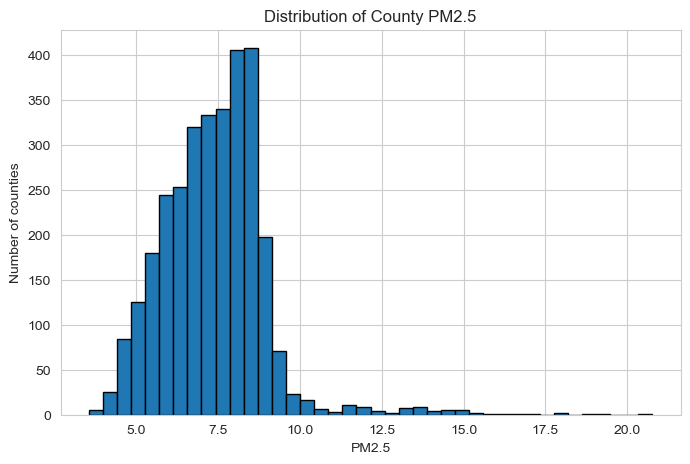

In [23]:
# One more diagnostic, to check for correct aggregation of PM25 values:
epa_county["PM25"].describe()

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(epa_county["PM25"].dropna(), bins=40, edgecolor="black")
plt.xlabel("PM2.5")
plt.ylabel("Number of counties")
plt.title("Distribution of County PM2.5")
plt.show()

Some counties are missing values because every tract in that county is missing that variable. Let's see which counties are so affected:

In [30]:
epa_county.loc[
    epa_county["PTRAF"].isna(),
    "state"
].value_counts()

Series([], Name: count, dtype: int64)

In [31]:
epa_county.to_csv("../data/epa_county.csv")

---
#### 2. Learn about the data

array([[<Axes: title={'center': 'PTRAF'}>,
        <Axes: title={'center': 'NO2'}>],
       [<Axes: title={'center': 'OZONE'}>,
        <Axes: title={'center': 'PM25'}>],
       [<Axes: title={'center': 'DSLPM'}>,
        <Axes: title={'center': 'RSEI_AIR'}>]], dtype=object)

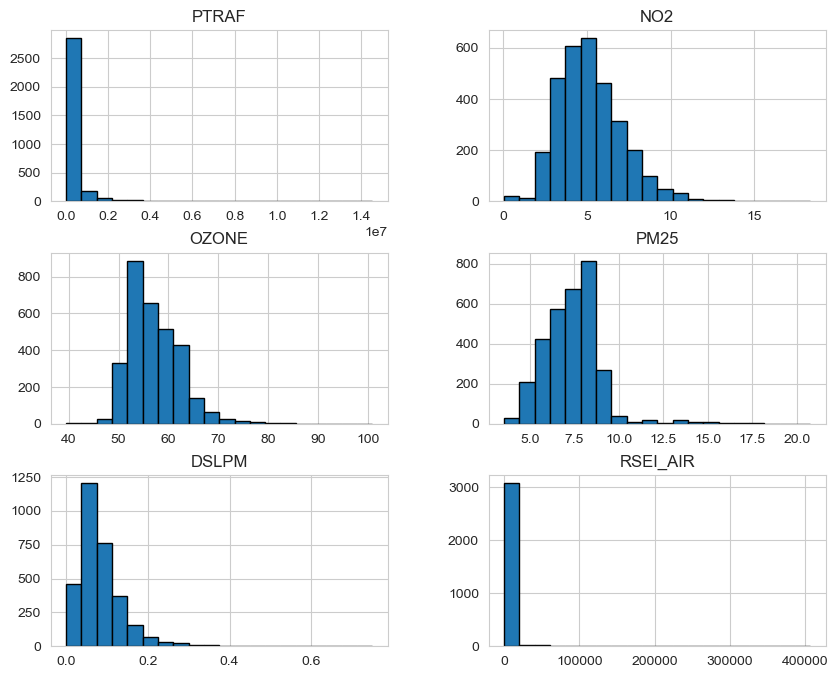

In [35]:
air_vars=["PTRAF", "NO2", "OZONE", "PM25", "DSLPM", "RSEI_AIR"]
epa_county[air_vars].hist(figsize=(10, 8), bins=20, edgecolor='black')

In [36]:
epa_county[air_vars].describe()

,PTRAF,NO2,OZONE,PM25,DSLPM,RSEI_AIR
count,3.144000e+03,3144.000000,3109.000000,3109.000000,3114.000000,3144.000000
mean,2.867081e+05,5.215276,57.135900,7.382344,0.085641,2814.658696
std,7.041174e+05,1.964534,5.278610,1.609051,0.059290,15830.859855
min,0.000000e+00,0.059275,39.463545,3.551251,0.000787,0.000000
25%,2.371281e+04,3.844276,53.157146,6.365669,0.048228,17.079100
50%,8.260263e+04,4.961854,56.213633,7.396431,0.072084,175.782035
75%,2.388713e+05,6.311901,60.478853,8.299963,0.106683,958.843978
max,1.453606e+07,18.344521,100.897911,20.766112,0.748876,407008.363420


---
#### 2. Climate and natural hazard risk 

This is from the National risk index dataset, using the variables:

- *RISK_SCORE*: National Risk Index - Score - Composite
- *EAL_SCORE*: 	Expected Annual Loss - Score - Composite
- *SOVI_SCORE*:	Social Vulnerability - Score
- *RESL_SCORE*:	Community Resilience - Score
  

In [37]:
nri_data = pd.read_csv("../data/NRI_Table_Counties/NRI_Table_Counties.csv")

columns=["STATE", "COUNTY", "STCOFIPS", "POPULATION", "AREA", "RISK_SCORE", "EAL_SCORE", "SOVI_SCORE", "RESL_SCORE"]
nri_data=nri_data[columns]

In [38]:
nri_data["STCOFIPS"] = nri_data["STCOFIPS"].astype(str).str.zfill(5)

nri_data.sample(5)

,STATE,COUNTY,STCOFIPS,POPULATION,AREA,RISK_SCORE,EAL_SCORE,SOVI_SCORE,RESL_SCORE
2580,Texas,Donley,48129,3257,942.465402,26.622137,20.173267,72.519084,13.486005
1749,Nevada,Lyon,32019,59117,2046.497303,71.405852,75.000000,25.190840,14.472010
647,Illinois,Madison,17119,265727,747.512234,93.416031,94.306931,25.890585,86.195929
1734,Nebraska,Valley,31175,4059,576.217075,26.017812,30.940594,33.206107,40.807888
545,Idaho,Adams,16003,4357,1383.333424,39.567430,35.581683,60.559796,8.587786


In [40]:
## Which counties are missing data?
missing_nri = nri_data[nri_data["RISK_SCORE"].isna()]

missing_nri[["STATE","COUNTY","STCOFIPS"]]

,STATE,COUNTY,STCOFIPS
3135,American Samoa,Eastern,60010
3136,American Samoa,Manu'a,60020
3137,American Samoa,Western,60050
3138,Guam,Guam,66010
3139,Northern Mariana Islands,Rota,69100
...,...,...,...
3218,Puerto Rico,Yabucoa,72151
3219,Puerto Rico,Yauco,72153
3220,Virgin Islands,St. Croix,78010
3221,Virgin Islands,St. John,78020


In [41]:
(
    nri_data["RISK_SCORE"].isna()
    ==
    nri_data["SOVI_SCORE"].isna()
).all()

(
    nri_data["RISK_SCORE"].isna()
    ==
    nri_data["RESL_SCORE"].isna()
).all()

np.True_

In [42]:
missing_nri["STATE"].value_counts()

STATE
Puerto Rico                 78
American Samoa               3
Northern Mariana Islands     3
Virgin Islands               3
Guam                         1
Name: count, dtype: int64

**Remark:**

NRI data is missing mostly from territories, most likely because FEMA does not compute composite NRI scores for U.S. territories.

In [43]:
# Remove US territories from dataset, since they mostly have missing NRI data:
territories = [
    "Puerto Rico",
    "American Samoa",
    "Guam",
    "Virgin Islands",
    "Northern Mariana Islands"
]

nri_data = nri_data[
    ~nri_data["STATE"].isin(territories)
].copy()

In [45]:
len(nri_data["RISK_SCORE"].isna())

3144

array([[<Axes: title={'center': 'POPULATION'}>,
        <Axes: title={'center': 'AREA'}>],
       [<Axes: title={'center': 'RISK_SCORE'}>,
        <Axes: title={'center': 'EAL_SCORE'}>],
       [<Axes: title={'center': 'SOVI_SCORE'}>,
        <Axes: title={'center': 'RESL_SCORE'}>]], dtype=object)

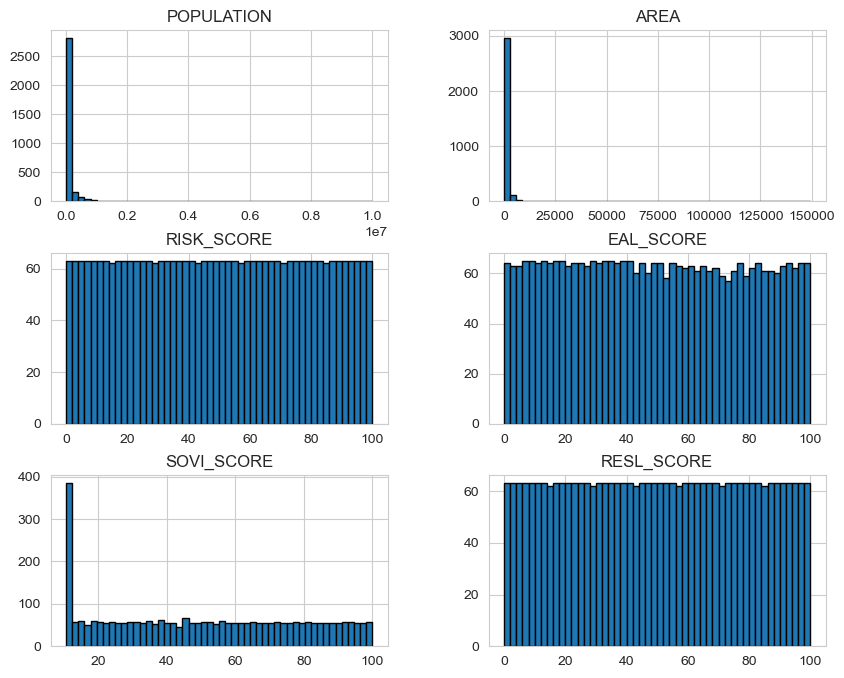

In [46]:
nri_data.hist(figsize=(10, 8), bins=50, edgecolor='black')

In [47]:
nri_data.to_csv("../data/nri_data_CLEAN.csv")

#### 3. Cancer and non-cancer risk data

In [7]:
## On non-cancer hazard risks:
non_can=pd.read_excel("../data/Food Environment/nata2014v2_national_allhi.xlsx")
non_can.head()


,Tract,Population,Respiratory HI,Neurological HI,Liver HI,Developmental HI,Reproductive HI,Kidney HI,Ocular HI,Endocrine HI,Hematological HI,Immunological HI,Skeletal HI,Spleen HI,Thyroid HI,Whole Body HI
0,0,312572412,0.436622,0.041939,0.014928,0.037268,0.051583,0.010736,8.439492e-06,0.000004,2.078270e-06,0.024822,0.000224,0.000106,0.008953,0.002224
1,1000000000,4779690,0.655975,0.035416,0.012497,0.052604,0.065680,0.007498,9.366032e-08,0.000004,3.349246e-07,0.019632,0.000155,0.000180,0.006015,0.000150
2,1001000000,54571,0.799127,0.038198,0.011782,0.062827,0.079101,0.005948,1.766050e-10,0.000002,2.333518e-07,0.017973,0.000056,0.000003,0.009789,0.000187
3,1001020100,1912,0.788052,0.037008,0.011426,0.061682,0.078886,0.005549,2.030090e-10,0.000002,2.896206e-07,0.016504,0.000075,0.000003,0.011047,0.000191
4,1001020200,2170,0.808744,0.043448,0.012986,0.064470,0.082523,0.006953,2.402750e-10,0.000002,3.139884e-07,0.019033,0.000067,0.000003,0.012949,0.000196


In [4]:
# Inspect dataset: 
non_can.shape

(76727, 16)

In [5]:
non_can.isna().sum().sort_values(ascending=False)

Tract               0
Population          0
Respiratory HI      0
Neurological HI     0
Liver HI            0
Developmental HI    0
Reproductive HI     0
Kidney HI           0
Ocular HI           0
Endocrine HI        0
Hematological HI    0
Immunological HI    0
Skeletal HI         0
Spleen HI           0
Thyroid HI          0
Whole Body HI       0
dtype: int64

In [8]:
# Aggregate the tract-level dataset to the county level first, using a population-weighted average,
# and then merge with other county-level datasets using the county FIPS code

non_can["Tract"] = non_can["Tract"].astype(str).str.zfill(11)
non_can["county_fips"] = non_can["Tract"].str[:5]

# keep_cols=["Tract", "county_fips", "Population", "Whole Body HI"]
# non_can=non_can[keep_cols]
hi_vars = [col for col in non_can.columns if "HI" in col]

# non_cancer_risk = (
#     non_can
#     .groupby("county_fips", as_index=False)[["Population", "Whole Body HI"]]
#     .sum()
# )

def weighted_mean(group, column, weight_col="Population"):
    x = group[column]
    w = group[weight_col]

    valid = x.notna() & w.notna() & (w > 0)

    if valid.sum() == 0:
        return np.nan

    return np.average(x[valid], weights=w[valid])


def aggregate_hi_county(group):
    result = {
        "Population": group["Population"].sum()
    }

    for var in hi_vars:
        result[var] = weighted_mean(group, var)

    return pd.Series(result)


non_cancer_risk = (
    non_can
    .groupby("county_fips")
    .apply(aggregate_hi_county, include_groups=False)
    .reset_index()
    .rename(columns={"county_fips": "FIPS"})
)

non_cancer_risk.head()


,FIPS,Population,Respiratory HI,Neurological HI,Liver HI,Developmental HI,Reproductive HI,Kidney HI,Ocular HI,Endocrine HI,Hematological HI,Immunological HI,Skeletal HI,Spleen HI,Thyroid HI,Whole Body HI
0,00000,312572412.0,0.436622,0.041939,0.014928,0.037268,0.051583,0.010736,8.439492e-06,4.481894e-06,2.078270e-06,0.024822,0.000224,1.060044e-04,0.008953,0.002224
1,01000,4779690.0,0.655975,0.035416,0.012497,0.052604,0.065680,0.007498,9.366032e-08,4.409909e-06,3.349246e-07,0.019632,0.000155,1.796079e-04,0.006015,0.000150
2,01001,109142.0,0.799127,0.038198,0.011782,0.062827,0.079101,0.005948,1.766051e-10,1.576253e-06,2.333518e-07,0.017973,0.000056,2.503434e-06,0.009789,0.000187
3,01003,364530.0,0.523780,0.027525,0.008522,0.039181,0.046159,0.002870,3.103023e-07,1.635022e-06,2.813044e-07,0.012382,0.000027,3.376943e-09,0.004429,0.000102
4,01005,54914.0,0.807123,0.025123,0.008279,0.078498,0.096981,0.002833,2.287435e-09,7.808706e-07,2.019220e-08,0.012559,0.002610,3.297103e-06,0.002180,0.000209


In [9]:
non_cancer_risk

,FIPS,Population,Respiratory HI,Neurological HI,Liver HI,Developmental HI,Reproductive HI,Kidney HI,Ocular HI,Endocrine HI,Hematological HI,Immunological HI,Skeletal HI,Spleen HI,Thyroid HI,Whole Body HI
0,00000,312572412.0,0.436622,0.041939,0.014928,0.037268,0.051583,0.010736,8.439492e-06,4.481894e-06,2.078270e-06,0.024822,0.000224,1.060044e-04,0.008953,2.223610e-03
1,01000,4779690.0,0.655975,0.035416,0.012497,0.052604,0.065680,0.007498,9.366032e-08,4.409909e-06,3.349246e-07,0.019632,0.000155,1.796079e-04,0.006015,1.498002e-04
2,01001,109142.0,0.799127,0.038198,0.011782,0.062827,0.079101,0.005948,1.766051e-10,1.576253e-06,2.333518e-07,0.017973,0.000056,2.503434e-06,0.009789,1.866579e-04
3,01003,364530.0,0.523780,0.027525,0.008522,0.039181,0.046159,0.002870,3.103023e-07,1.635022e-06,2.813044e-07,0.012382,0.000027,3.376943e-09,0.004429,1.015472e-04
4,01005,54914.0,0.807123,0.025123,0.008279,0.078498,0.096981,0.002833,2.287435e-09,7.808706e-07,2.019220e-08,0.012559,0.002610,3.297103e-06,0.002180,2.090122e-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3272,72153,84086.0,0.259476,0.021222,0.011555,0.052744,0.063696,0.001859,1.387842e-09,5.510940e-07,1.032801e-07,0.009647,0.000000,0.000000e+00,0.004153,1.843725e-04
3273,78000,106405.0,0.123560,0.017997,0.007832,0.010295,0.013787,0.001557,2.103254e-08,8.709705e-07,1.642596e-08,0.013003,0.000000,0.000000e+00,0.001041,3.993962e-07
3274,78010,101202.0,0.100706,0.016973,0.007288,0.006705,0.009862,0.000950,3.079986e-08,9.619207e-07,2.106776e-09,0.006679,0.000000,0.000000e+00,0.000976,3.413507e-07
3275,78020,8340.0,0.086366,0.017092,0.006844,0.004185,0.004974,0.000513,3.836556e-10,1.117612e-07,3.313712e-09,0.005929,0.000000,0.000000e+00,0.002524,5.269141e-07


In [19]:
# Remove state/national summary entries:
non_cancer_risk = non_cancer_risk[~non_cancer_risk["FIPS"].str.endswith("000", na=False)]
non_cancer_risk

,FIPS,Population,Respiratory HI,Neurological HI,Liver HI,Developmental HI,Reproductive HI,Kidney HI,Ocular HI,Endocrine HI,Hematological HI,Immunological HI,Skeletal HI,Spleen HI,Thyroid HI,Whole Body HI
2,01001,109142.0,0.799127,0.038198,0.011782,0.062827,0.079101,0.005948,1.766051e-10,1.576253e-06,2.333518e-07,0.017973,0.000056,2.503434e-06,0.009789,1.866579e-04
3,01003,364530.0,0.523780,0.027525,0.008522,0.039181,0.046159,0.002870,3.103023e-07,1.635022e-06,2.813044e-07,0.012382,0.000027,3.376943e-09,0.004429,1.015472e-04
4,01005,54914.0,0.807123,0.025123,0.008279,0.078498,0.096981,0.002833,2.287435e-09,7.808706e-07,2.019220e-08,0.012559,0.002610,3.297103e-06,0.002180,2.090122e-04
5,01007,45830.0,0.723578,0.024480,0.009019,0.052060,0.062871,0.003757,3.720953e-09,1.972280e-06,2.663810e-07,0.013410,0.000071,3.232020e-05,0.001929,1.512177e-04
6,01009,114644.0,0.572684,0.030272,0.009509,0.043371,0.051517,0.004126,4.574036e-09,1.049502e-06,9.224831e-08,0.014146,0.000050,2.523939e-05,0.005514,1.437943e-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3271,72151,75882.0,0.255217,0.017506,0.006942,0.049257,0.057481,0.002759,3.284859e-10,2.943288e-07,5.419704e-06,0.008046,0.000001,0.000000e+00,0.001335,1.848769e-04
3272,72153,84086.0,0.259476,0.021222,0.011555,0.052744,0.063696,0.001859,1.387842e-09,5.510940e-07,1.032801e-07,0.009647,0.000000,0.000000e+00,0.004153,1.843725e-04
3274,78010,101202.0,0.100706,0.016973,0.007288,0.006705,0.009862,0.000950,3.079986e-08,9.619207e-07,2.106776e-09,0.006679,0.000000,0.000000e+00,0.000976,3.413507e-07
3275,78020,8340.0,0.086366,0.017092,0.006844,0.004185,0.004974,0.000513,3.836556e-10,1.117612e-07,3.313712e-09,0.005929,0.000000,0.000000e+00,0.002524,5.269141e-07


In [20]:
non_cancer_risk.to_csv("../data/non_cancer_risk.csv")

In [21]:
# On cancer risk:
cancer_risk=pd.read_excel("../data/Food Environment/nata2014v2_national_cancerrisk_by_tract_srcgrp.xlsx")

keep=["State", "FIPS", "County", "Population", "Total Cancer Risk (per million)"]
cancer_risk = cancer_risk[keep] 

cancer_risk["FIPS"] = cancer_risk["FIPS"].astype(str).str.zfill(5)

cancer_risk

,State,FIPS,County,Population,Total Cancer Risk (per million)
0,US,00000,Entire US,312572412,31.689004
1,AL,01000,Entire State,4779690,43.314142
2,AL,01001,Autauga,54571,49.511426
3,AL,01001,Autauga,1912,49.377032
4,AL,01001,Autauga,2170,50.320741
...,...,...,...,...,...
76722,VI,78030,St. Thomas,4088,14.181113
76723,VI,78030,St. Thomas,4878,10.419422
76724,VI,78030,St. Thomas,5220,12.686213
76725,VI,78030,St. Thomas,4356,11.224384


Compress data to one entry per county:

In [13]:
geo_lookup_2 = cancer_risk[["FIPS", "State", "County"]].drop_duplicates()

In [14]:
cancer_risk_data= (
    cancer_risk
    .groupby("FIPS")[["Population", "Total Cancer Risk (per million)"]]
    .sum()
    .reset_index()
)
cancer_risk_data["FIPS"] = cancer_risk_data["FIPS"].astype(str).str.zfill(5)


In [15]:
cancer_risk_data = cancer_risk_data.merge(geo_lookup_2, on="FIPS", how="left")

cancer_risk_data

,FIPS,Population,Total Cancer Risk (per million),State,County
0,00000,312572412,31.689004,US,Entire US
1,01000,4779690,43.314142,AL,Entire State
2,01001,109142,641.344644,AL,Autauga
3,01003,364530,1131.580093,AL,Baldwin
4,01005,54914,457.387006,AL,Barbour
...,...,...,...,...,...
3272,72153,84086,204.795316,PR,Yauco
3273,78000,106405,10.693877,VI,Entire State
3274,78010,101202,158.828209,VI,St. Croix
3275,78020,8340,27.193711,VI,St. John


In [17]:
cancer_risk_data = cancer_risk_data[cancer_risk_data["FIPS"] != 0].copy()

In [18]:
# Remove entries corresponding to "entire US" or "entire state"

cancer_risk_data = cancer_risk_data[~cancer_risk_data["FIPS"].str.endswith("000", na=False)]
cancer_risk_data

,FIPS,Population,Total Cancer Risk (per million),State,County
2,01001,109142,641.344644,AL,Autauga
3,01003,364530,1131.580093,AL,Baldwin
4,01005,54914,457.387006,AL,Barbour
5,01007,45830,229.922349,AL,Bibb
6,01009,114644,391.032211,AL,Blount
...,...,...,...,...,...
3271,72151,75882,153.421453,PR,Yabucoa
3272,72153,84086,204.795316,PR,Yauco
3274,78010,101202,158.828209,VI,St. Croix
3275,78020,8340,27.193711,VI,St. John


In [51]:
cancer_risk_data["FIPS"].duplicated().sum()

np.int64(0)

In [52]:
cancer_risk_data.groupby("FIPS").size().value_counts().sort_index()

1    3223
Name: count, dtype: int64

In [53]:
cancer_risk_data[["Population"]].describe()

,Population
count,3.223000e+03
mean,1.939636e+05
std,6.184004e+05
min,1.640000e+02
25%,2.265100e+04
50%,5.219400e+04
75%,1.315870e+05
max,1.963713e+07


In [54]:
cancer_risk_data.columns

Index(['FIPS', 'Population', 'Total Cancer Risk (per million)', 'State',
       'County'],
      dtype='object')

In [22]:
cancer_risk_data.to_csv("../data/cancer_risk_data.csv")

#### 4. Merge datasets

In [23]:
master = pd.read_csv("../data/identifiers/master.csv")
epa_county= pd.read_csv("../data/epa_county_CLEAN.csv")
nri_data=pd.read_csv("../data/nri_data_CLEAN.csv")

In [26]:
epa_county.head()

,Unnamed: 0,FIPS,state,state_code,county,Population,PM25,OZONE,NO2,DSLPM,PTRAF,RSEI_AIR
0,1,1001,ALABAMA,AL,Autauga County,58761.0,8.913208,50.662299,5.173662,0.098470,307790.990536,1649.308252
1,2,1003,ALABAMA,AL,Baldwin County,233420.0,9.175796,54.878235,3.587880,0.078929,211663.701507,522.689409
2,3,1005,ALABAMA,AL,Barbour County,24877.0,8.368747,52.365743,3.833613,0.047168,92922.233960,152.316386
3,4,1007,ALABAMA,AL,Bibb County,22251.0,8.562335,52.211148,2.595553,0.060176,48853.424324,2121.376387
4,5,1009,ALABAMA,AL,Blount County,59077.0,8.492552,55.096873,3.360859,0.077418,56869.288455,1379.140438


In [28]:
master["FIPS"] = master["FIPS"].astype(str).str.zfill(5)
epa_county["FIPS"] = epa_county["FIPS"].astype(str).str.zfill(5)

In [33]:
# Begin merging
# First merge EPA data
master_1 = master.merge(
 epa_county,
   left_on="FIPS",
   right_on="FIPS",
   how="left"
)

In [34]:
master_1.sample(5)

,Unnamed: 0_x,state_x,county_x,state_code_x,FIPS,Unnamed: 0_y,state_y,state_code_y,county_y,Population,PM25,OZONE,NO2,DSLPM,PTRAF,RSEI_AIR
1281,16536,MICHIGAN,LAPEER,MI,26087,1280.0,MICHIGAN,MI,Lapeer County,88687.0,6.815253,66.958217,4.707109,0.070727,9.852849e+04,172.965034
752,9657,INDIANA,MARION,IN,18097,751.0,INDIANA,IN,Marion County,971737.0,9.794644,61.840262,10.703818,0.266611,1.718232e+06,1836.047535
705,9145,INDIANA,ALLEN,IN,18003,704.0,INDIANA,IN,Allen County,385456.0,8.205086,62.882046,8.219727,0.196326,6.384793e+05,12861.168666
392,5979,FLORIDA,WASHINGTON,FL,12133,392.0,FLORIDA,FL,Washington County,25014.0,8.081649,53.094138,3.025823,0.045493,4.242758e+04,11.235658
2752,35290,TEXAS,TARRANT,TX,48439,2748.0,TEXAS,TX,Tarrant County,2113854.0,8.897931,68.351383,11.371172,0.189045,1.214897e+06,739.677168


In [35]:
master_1 = master_1.iloc[:, ~master_1.columns.str.endswith("_x")]
#master_1 = master_1.loc[:, ~master_1.columns.str.endswith("_y")]
# master_1 = master_1.drop(columns=["STATE_NAME", "CNTY_NAME"])
master_1.head()

,FIPS,Unnamed: 0_y,state_y,state_code_y,county_y,Population,PM25,OZONE,NO2,DSLPM,PTRAF,RSEI_AIR
0,01001,1.0,ALABAMA,AL,Autauga County,58761.0,8.913208,50.662299,5.173662,0.098470,307790.990536,1649.308252
1,01003,2.0,ALABAMA,AL,Baldwin County,233420.0,9.175796,54.878235,3.587880,0.078929,211663.701507,522.689409
2,01005,3.0,ALABAMA,AL,Barbour County,24877.0,8.368747,52.365743,3.833613,0.047168,92922.233960,152.316386
3,01007,4.0,ALABAMA,AL,Bibb County,22251.0,8.562335,52.211148,2.595553,0.060176,48853.424324,2121.376387
4,01009,5.0,ALABAMA,AL,Blount County,59077.0,8.492552,55.096873,3.360859,0.077418,56869.288455,1379.140438


In [37]:
# Check which counties did not get matched to EPA data:
missing_counties = set(master_1["FIPS"]) - set(epa_county["FIPS"])
print(len(missing_counties))
print(list(missing_counties)[:10])

20
['02232', '46113', '02261', '09005', '09001', '02201', '32119', '09007', '09009', '09013']


In [41]:
print(master_1["FIPS"].dtype)
print(nri_data["STCOFIPS"].dtype)


object
int64


In [42]:
# Continue merging,
# With NRI data
# Convert STCOFIPS to a padded 5-char string first:
nri_data["STCOFIPS"] = (
    nri_data["STCOFIPS"]
    .astype(str)
    .str.strip()
    .str.zfill(5)
)

master_2 = master_1.merge(
    nri_data,
    left_on="FIPS",
    right_on="STCOFIPS",
    how="left"
)

In [43]:
master_2

,FIPS,Unnamed: 0_y,state_y,state_code_y,county_y,Population,PM25,OZONE,NO2,DSLPM,...,Unnamed: 0,STATE,COUNTY,STCOFIPS,POPULATION,AREA,RISK_SCORE,EAL_SCORE,SOVI_SCORE,RESL_SCORE
0,01001,1.0,ALABAMA,AL,Autauga County,58761.0,8.913208,50.662299,5.173662,0.098470,...,0.0,Alabama,Autauga,01001,58764.0,610.470508,57.569975,59.870050,38.040712,55.120865
1,01003,2.0,ALABAMA,AL,Baldwin County,233420.0,9.175796,54.878235,3.587880,0.078929,...,1.0,Alabama,Baldwin,01003,231365.0,2047.738775,96.723919,96.627475,44.243003,93.002545
2,01005,3.0,ALABAMA,AL,Barbour County,24877.0,8.368747,52.365743,3.833613,0.047168,...,2.0,Alabama,Barbour,01005,25160.0,913.646511,48.123410,30.538366,96.374046,11.164122
3,01007,4.0,ALABAMA,AL,Bibb County,22251.0,8.562335,52.211148,2.595553,0.060176,...,3.0,Alabama,Bibb,01007,22239.0,632.486798,39.122137,31.002475,75.254453,22.169211
4,01009,5.0,ALABAMA,AL,Blount County,59077.0,8.492552,55.096873,3.360859,0.077418,...,4.0,Alabama,Blount,01009,58992.0,657.196555,68.479644,62.345297,69.338422,15.648855
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3149,56037,3143.0,WYOMING,WY,Sweetwater County,42079.0,4.282689,63.228821,8.105548,0.154190,...,3130.0,Wyoming,Sweetwater,56037,42238.0,10597.073996,30.629771,40.841584,19.338422,16.380407
3150,56039,3144.0,WYOMING,WY,Teton County,23346.0,4.445018,61.689650,5.090137,0.030738,...,3131.0,Wyoming,Teton,56039,23250.0,4259.833177,70.642494,79.919554,10.623410,42.461832
3151,56041,3145.0,WYOMING,WY,Uinta County,20546.0,5.523874,66.295652,9.163653,0.095233,...,3132.0,Wyoming,Uinta,56041,20412.0,2109.220457,16.698473,26.206683,14.949109,12.531807
3152,56043,3146.0,WYOMING,WY,Washakie County,7725.0,4.568317,60.398357,7.284553,0.030635,...,3133.0,Wyoming,Washakie,56043,7662.0,2265.341661,24.363868,17.914604,79.452926,55.375318


In [44]:
# Check for correct mergin: 
print(master_2.shape)
print(master_2["STCOFIPS"].isna().sum())

(3154, 22)
20


In [45]:
# Drop unnecessary duplicate/index columns from merge
cols_to_drop = [
    "Unnamed: 0_y",
    "Unnamed: 0",
    "STATE",
    "COUNTY",
    "STCOFIPS",
    "POPULATION"
]

master_2 = master_2.drop(
    columns=[c for c in cols_to_drop if c in master_2.columns]
)

# Optional: clean column names
master_2.columns = master_2.columns.str.strip()
master_2.head()

,FIPS,state_y,state_code_y,county_y,Population,PM25,OZONE,NO2,DSLPM,PTRAF,RSEI_AIR,AREA,RISK_SCORE,EAL_SCORE,SOVI_SCORE,RESL_SCORE
0,01001,ALABAMA,AL,Autauga County,58761.0,8.913208,50.662299,5.173662,0.098470,307790.990536,1649.308252,610.470508,57.569975,59.870050,38.040712,55.120865
1,01003,ALABAMA,AL,Baldwin County,233420.0,9.175796,54.878235,3.587880,0.078929,211663.701507,522.689409,2047.738775,96.723919,96.627475,44.243003,93.002545
2,01005,ALABAMA,AL,Barbour County,24877.0,8.368747,52.365743,3.833613,0.047168,92922.233960,152.316386,913.646511,48.123410,30.538366,96.374046,11.164122
3,01007,ALABAMA,AL,Bibb County,22251.0,8.562335,52.211148,2.595553,0.060176,48853.424324,2121.376387,632.486798,39.122137,31.002475,75.254453,22.169211
4,01009,ALABAMA,AL,Blount County,59077.0,8.492552,55.096873,3.360859,0.077418,56869.288455,1379.140438,657.196555,68.479644,62.345297,69.338422,15.648855


In [46]:
# Check which counties did not get matched to NRI data:
missing_counties = set(master_2["FIPS"]) - set(nri_data["STCOFIPS"])
print(len(missing_counties))
print(list(missing_counties)[:10])

20
['02232', '46113', '02261', '09005', '09001', '02201', '32119', '09007', '09009', '09013']


In [47]:
## Merge with cancer-risk data
master_3= master_2.merge(
   cancer_risk_data,
    left_on="FIPS",
     right_on="FIPS", 
    how="left"
 )

In [48]:
master_3

,FIPS,state_y,state_code_y,county_y,Population_x,PM25,OZONE,NO2,DSLPM,PTRAF,RSEI_AIR,AREA,RISK_SCORE,EAL_SCORE,SOVI_SCORE,RESL_SCORE,Population_y,Total Cancer Risk (per million),State,County
0,01001,ALABAMA,AL,Autauga County,58761.0,8.913208,50.662299,5.173662,0.098470,307790.990536,1649.308252,610.470508,57.569975,59.870050,38.040712,55.120865,109142.0,641.344644,AL,Autauga
1,01003,ALABAMA,AL,Baldwin County,233420.0,9.175796,54.878235,3.587880,0.078929,211663.701507,522.689409,2047.738775,96.723919,96.627475,44.243003,93.002545,364530.0,1131.580093,AL,Baldwin
2,01005,ALABAMA,AL,Barbour County,24877.0,8.368747,52.365743,3.833613,0.047168,92922.233960,152.316386,913.646511,48.123410,30.538366,96.374046,11.164122,54914.0,457.387006,AL,Barbour
3,01007,ALABAMA,AL,Bibb County,22251.0,8.562335,52.211148,2.595553,0.060176,48853.424324,2121.376387,632.486798,39.122137,31.002475,75.254453,22.169211,45830.0,229.922349,AL,Bibb
4,01009,ALABAMA,AL,Blount County,59077.0,8.492552,55.096873,3.360859,0.077418,56869.288455,1379.140438,657.196555,68.479644,62.345297,69.338422,15.648855,114644.0,391.032211,AL,Blount
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3149,56037,WYOMING,WY,Sweetwater County,42079.0,4.282689,63.228821,8.105548,0.154190,259437.481534,109.410993,10597.073996,30.629771,40.841584,19.338422,16.380407,87612.0,204.023753,WY,Sweetwater
3150,56039,WYOMING,WY,Teton County,23346.0,4.445018,61.689650,5.090137,0.030738,111022.830945,0.000000,4259.833177,70.642494,79.919554,10.623410,42.461832,42588.0,63.685742,WY,Teton
3151,56041,WYOMING,WY,Uinta County,20546.0,5.523874,66.295652,9.163653,0.095233,152795.860187,11.414990,2109.220457,16.698473,26.206683,14.949109,12.531807,42236.0,59.797837,WY,Uinta
3152,56043,WYOMING,WY,Washakie County,7725.0,4.568317,60.398357,7.284553,0.030635,66859.446596,198.414098,2265.341661,24.363868,17.914604,79.452926,55.375318,17066.0,63.818744,WY,Washakie


In [50]:
master_3[["Population_x", "Population_y"]].corr()

,Population_x,Population_y
Population_x,1.000000,0.997676
Population_y,0.997676,1.000000


In [55]:
master_3 = (
    master_3
    .drop(columns=["state_code_y", "county_y", "state_y", "Population_y"])
    .rename(columns={"Population_x": "Population"})
)
master_3.head()

,FIPS,Population,PM25,OZONE,NO2,DSLPM,PTRAF,RSEI_AIR,AREA,RISK_SCORE,EAL_SCORE,SOVI_SCORE,RESL_SCORE,Total Cancer Risk (per million),State,County
0,01001,58761.0,8.913208,50.662299,5.173662,0.098470,307790.990536,1649.308252,610.470508,57.569975,59.870050,38.040712,55.120865,641.344644,AL,Autauga
1,01003,233420.0,9.175796,54.878235,3.587880,0.078929,211663.701507,522.689409,2047.738775,96.723919,96.627475,44.243003,93.002545,1131.580093,AL,Baldwin
2,01005,24877.0,8.368747,52.365743,3.833613,0.047168,92922.233960,152.316386,913.646511,48.123410,30.538366,96.374046,11.164122,457.387006,AL,Barbour
3,01007,22251.0,8.562335,52.211148,2.595553,0.060176,48853.424324,2121.376387,632.486798,39.122137,31.002475,75.254453,22.169211,229.922349,AL,Bibb
4,01009,59077.0,8.492552,55.096873,3.360859,0.077418,56869.288455,1379.140438,657.196555,68.479644,62.345297,69.338422,15.648855,391.032211,AL,Blount


In [56]:
# Check how many counties missing cancer risk data:
missing_counties = set(master_3["FIPS"]) - set(cancer_risk_data["FIPS"])
print(len(missing_counties))
print(list(missing_counties)[:10])

12
['00000', '02232', '08145', '02201', '32119', '02066', '02280', '51515', '02158', '51560']


In [58]:
## Merge with non-cancer-risk data
master_4= master_3.merge(
   non_cancer_risk,
   left_on="FIPS",
    right_on="FIPS", 
    how="left" )

In [59]:
master_4.head()

,FIPS,Population_x,PM25,OZONE,NO2,DSLPM,PTRAF,RSEI_AIR,AREA,RISK_SCORE,...,Reproductive HI,Kidney HI,Ocular HI,Endocrine HI,Hematological HI,Immunological HI,Skeletal HI,Spleen HI,Thyroid HI,Whole Body HI
0,01001,58761.0,8.913208,50.662299,5.173662,0.098470,307790.990536,1649.308252,610.470508,57.569975,...,0.079101,0.005948,1.766051e-10,1.576253e-06,2.333518e-07,0.017973,0.000056,2.503434e-06,0.009789,0.000187
1,01003,233420.0,9.175796,54.878235,3.587880,0.078929,211663.701507,522.689409,2047.738775,96.723919,...,0.046159,0.002870,3.103023e-07,1.635022e-06,2.813044e-07,0.012382,0.000027,3.376943e-09,0.004429,0.000102
2,01005,24877.0,8.368747,52.365743,3.833613,0.047168,92922.233960,152.316386,913.646511,48.123410,...,0.096981,0.002833,2.287435e-09,7.808706e-07,2.019220e-08,0.012559,0.002610,3.297103e-06,0.002180,0.000209
3,01007,22251.0,8.562335,52.211148,2.595553,0.060176,48853.424324,2121.376387,632.486798,39.122137,...,0.062871,0.003757,3.720953e-09,1.972280e-06,2.663810e-07,0.013410,0.000071,3.232020e-05,0.001929,0.000151
4,01009,59077.0,8.492552,55.096873,3.360859,0.077418,56869.288455,1379.140438,657.196555,68.479644,...,0.051517,0.004126,4.574036e-09,1.049502e-06,9.224831e-08,0.014146,0.000050,2.523939e-05,0.005514,0.000144


In [60]:
master_4.columns

Index(['FIPS', 'Population_x', 'PM25', 'OZONE', 'NO2', 'DSLPM', 'PTRAF',
       'RSEI_AIR', 'AREA', 'RISK_SCORE', 'EAL_SCORE', 'SOVI_SCORE',
       'RESL_SCORE', 'Total Cancer Risk (per million)', 'State', 'County',
       'Population_y', 'Respiratory HI', 'Neurological HI', 'Liver HI',
       'Developmental HI', 'Reproductive HI', 'Kidney HI', 'Ocular HI',
       'Endocrine HI', 'Hematological HI', 'Immunological HI', 'Skeletal HI',
       'Spleen HI', 'Thyroid HI', 'Whole Body HI'],
      dtype='object')

In [61]:
master_4 = (
    master_4
    .drop(columns=["Population_y"])
    .rename(columns={"Population_x": "Population"})
)
master_4.head()

,FIPS,Population,PM25,OZONE,NO2,DSLPM,PTRAF,RSEI_AIR,AREA,RISK_SCORE,...,Reproductive HI,Kidney HI,Ocular HI,Endocrine HI,Hematological HI,Immunological HI,Skeletal HI,Spleen HI,Thyroid HI,Whole Body HI
0,01001,58761.0,8.913208,50.662299,5.173662,0.098470,307790.990536,1649.308252,610.470508,57.569975,...,0.079101,0.005948,1.766051e-10,1.576253e-06,2.333518e-07,0.017973,0.000056,2.503434e-06,0.009789,0.000187
1,01003,233420.0,9.175796,54.878235,3.587880,0.078929,211663.701507,522.689409,2047.738775,96.723919,...,0.046159,0.002870,3.103023e-07,1.635022e-06,2.813044e-07,0.012382,0.000027,3.376943e-09,0.004429,0.000102
2,01005,24877.0,8.368747,52.365743,3.833613,0.047168,92922.233960,152.316386,913.646511,48.123410,...,0.096981,0.002833,2.287435e-09,7.808706e-07,2.019220e-08,0.012559,0.002610,3.297103e-06,0.002180,0.000209
3,01007,22251.0,8.562335,52.211148,2.595553,0.060176,48853.424324,2121.376387,632.486798,39.122137,...,0.062871,0.003757,3.720953e-09,1.972280e-06,2.663810e-07,0.013410,0.000071,3.232020e-05,0.001929,0.000151
4,01009,59077.0,8.492552,55.096873,3.360859,0.077418,56869.288455,1379.140438,657.196555,68.479644,...,0.051517,0.004126,4.574036e-09,1.049502e-06,9.224831e-08,0.014146,0.000050,2.523939e-05,0.005514,0.000144


In [63]:
# Check how many counties missing cancer risk data:
missing_counties = set(master_4["FIPS"]) - set(non_cancer_risk["FIPS"])
print(len(missing_counties))
print(list(missing_counties)[:10])

12
['00000', '02232', '08145', '02201', '32119', '02066', '02280', '51515', '02158', '51560']


In [65]:
# Re-arrange the order of columns: 
# Identifier variables
id_cols = [
    "FIPS",
    "County",
    "State",
    "Population"
]

# EPA variables
epa_cols = [
    "PM25",
    "OZONE",
    "NO2",
    "DSLPM",
    "PTRAF",
    "RSEI_AIR"
]

# NRI variables
nri_cols = [
    "AREA",
    "RISK_SCORE",
    "EAL_SCORE",
    "SOVI_SCORE",
    "RESL_SCORE"
]

# Cancer variable
cancer_cols = [
    "Total Cancer Risk (per million)"
]

# Hazard Index variables
hi_cols = [
    "Respiratory HI",
    "Neurological HI",
    "Liver HI",
    "Developmental HI",
    "Reproductive HI",
    "Kidney HI",
    "Ocular HI",
    "Endocrine HI",
    "Hematological HI",
    "Immunological HI",
    "Skeletal HI",
    "Spleen HI",
    "Thyroid HI",
    "Whole Body HI"
]

# Keep only columns that actually exist
new_order = (
    [c for c in id_cols if c in master_4.columns] +
    [c for c in epa_cols if c in master_4.columns] +
    [c for c in nri_cols if c in master_4.columns] +
    [c for c in cancer_cols if c in master_4.columns] +
    [c for c in hi_cols if c in master_4.columns]
)

master_4 = master_4[new_order]

In [66]:
master_4.head()

,FIPS,County,State,Population,PM25,OZONE,NO2,DSLPM,PTRAF,RSEI_AIR,...,Reproductive HI,Kidney HI,Ocular HI,Endocrine HI,Hematological HI,Immunological HI,Skeletal HI,Spleen HI,Thyroid HI,Whole Body HI
0,01001,Autauga,AL,58761.0,8.913208,50.662299,5.173662,0.098470,307790.990536,1649.308252,...,0.079101,0.005948,1.766051e-10,1.576253e-06,2.333518e-07,0.017973,0.000056,2.503434e-06,0.009789,0.000187
1,01003,Baldwin,AL,233420.0,9.175796,54.878235,3.587880,0.078929,211663.701507,522.689409,...,0.046159,0.002870,3.103023e-07,1.635022e-06,2.813044e-07,0.012382,0.000027,3.376943e-09,0.004429,0.000102
2,01005,Barbour,AL,24877.0,8.368747,52.365743,3.833613,0.047168,92922.233960,152.316386,...,0.096981,0.002833,2.287435e-09,7.808706e-07,2.019220e-08,0.012559,0.002610,3.297103e-06,0.002180,0.000209
3,01007,Bibb,AL,22251.0,8.562335,52.211148,2.595553,0.060176,48853.424324,2121.376387,...,0.062871,0.003757,3.720953e-09,1.972280e-06,2.663810e-07,0.013410,0.000071,3.232020e-05,0.001929,0.000151
4,01009,Blount,AL,59077.0,8.492552,55.096873,3.360859,0.077418,56869.288455,1379.140438,...,0.051517,0.004126,4.574036e-09,1.049502e-06,9.224831e-08,0.014146,0.000050,2.523939e-05,0.005514,0.000144


In [67]:
master_4.to_csv("../data/master_pollution_data.csv")